In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Стили графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


  ЗАДАНИЕ 2: Имитационное моделирование двухканальной СМО

    λ - интенсивность потока заявок
    μ - интенсивность обработки заявок
    T - время моделирования, сек
  Параметры: λ = 0.2, μ = 0.1, T = 1000 сек

  Результаты имитационного моделирования (T = 1000 сек)
  Всего поступило заявок:                    182
  Число обработанных заявок:                  113
  Число отказов:                              69
  Вероятность обработки заявки (Q):           0.6209
  Вероятность отказа (Pf):                    0.3791
  Время простоя 1-го канала (Tp1):            309.81 сек
  Время простоя 2-го канала (Tp2):            505.85 сек
  Вероятность загрузки 1-го канала:           0.6902
  Вероятность загрузки 2-го канала:           0.4941
  Вер-ть загрузки хотя бы одного канала:     0.8068
  ЗАДАНИЕ 3.1: Сопоставление с аналитическими результатами (ТМО)

  Аналитические результаты (ТМО, M/M/2/2)
  ρ = λ/μ:                                    2.0000
  P₀ (вероятность простоя системы):         

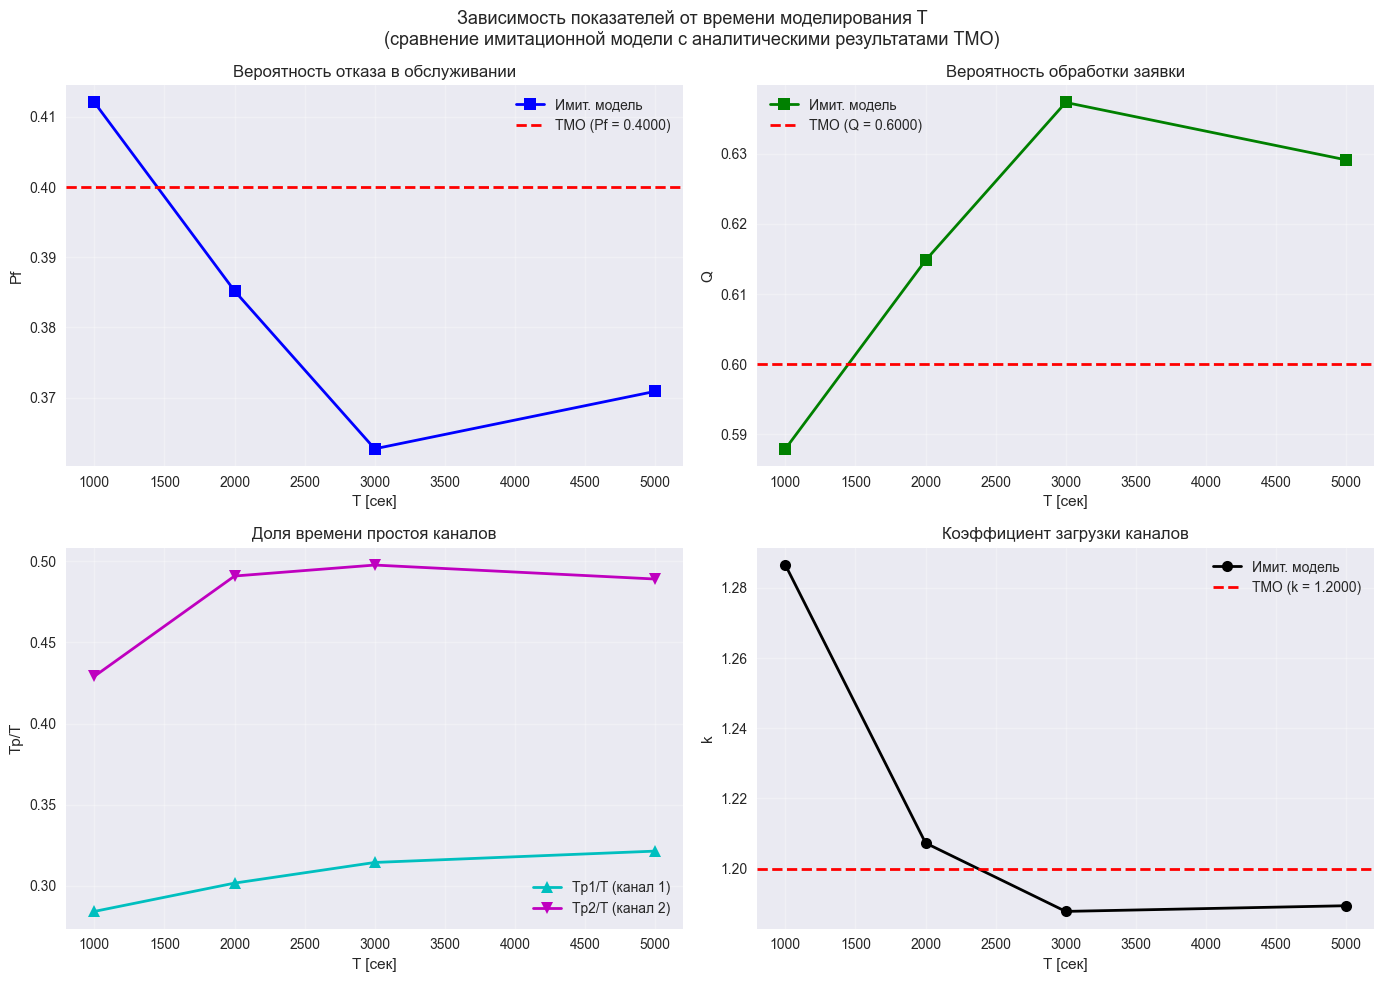

In [2]:
import numpy as np
import heapq
import matplotlib.pyplot as plt


# ==================== ЗАДАНИЕ 1: Имитационная модель ====================

def simulate_two_channel(lam, mu, T, seed=42):
    """
    Имитационное моделирование двухканальной СМО с отказами (M/M/2/2).

    Параметры:
        lam  — интенсивность входного потока (λ) [1/сек]
        mu   — интенсивность обслуживания (μ) [1/сек]
        T    — время моделирования [сек]
        seed — начальное значение ГСЧ

    Возвращает словарь с результатами моделирования.
    """
    rng = np.random.RandomState(seed)

    # Очередь событий (мин-куча): (время, тип_события)
    # тип: 0 — приход заявки, 1 — уход из канала 1, 2 — уход из канала 2
    events = []
    heapq.heappush(events, (rng.exponential(1.0 / lam), 0))

    ch1_busy = False
    ch2_busy = False

    total_requests = 0
    processed = 0
    rejected = 0

    prev_time = 0.0
    ch1_busy_time = 0.0
    ch2_busy_time = 0.0
    time_state = [0.0, 0.0, 0.0]  # время в состоянии с 0, 1, 2 занятыми каналами

    while events:
        t, etype = heapq.heappop(events)

        if t >= T:
            break

        # Обновляем статистику по времени
        dt = t - prev_time
        n_busy = int(ch1_busy) + int(ch2_busy)
        time_state[n_busy] += dt
        if ch1_busy:
            ch1_busy_time += dt
        if ch2_busy:
            ch2_busy_time += dt
        prev_time = t

        if etype == 0:  # Приход заявки
            total_requests += 1

            if not ch1_busy:
                # Канал 1 свободен — обслуживаем
                processed += 1
                ch1_busy = True
                service_time = rng.exponential(1.0 / mu)
                heapq.heappush(events, (t + service_time, 1))
            elif not ch2_busy:
                # Канал 2 свободен — обслуживаем
                processed += 1
                ch2_busy = True
                service_time = rng.exponential(1.0 / mu)
                heapq.heappush(events, (t + service_time, 2))
            else:
                # Оба канала заняты — отказ
                rejected += 1

            # Планируем следующий приход заявки
            next_arrival = t + rng.exponential(1.0 / lam)
            heapq.heappush(events, (next_arrival, 0))

        elif etype == 1:  # Завершение обслуживания в канале 1
            ch1_busy = False

        elif etype == 2:  # Завершение обслуживания в канале 2
            ch2_busy = False

    # Учитываем оставшееся время до T
    dt = T - prev_time
    if dt > 0:
        n_busy = int(ch1_busy) + int(ch2_busy)
        time_state[n_busy] += dt
        if ch1_busy:
            ch1_busy_time += dt
        if ch2_busy:
            ch2_busy_time += dt

    # Вычисление показателей
    ch1_idle_time = T - ch1_busy_time
    ch2_idle_time = T - ch2_busy_time

    prob_rejection = rejected / total_requests if total_requests > 0 else 0.0
    prob_processing = processed / total_requests if total_requests > 0 else 1.0
    prob_load_ch1 = ch1_busy_time / T
    prob_load_ch2 = ch2_busy_time / T
    prob_idle_system = time_state[0] / T       # P₀ — вероятность простоя системы
    prob_load_either = 1.0 - prob_idle_system   # вероятность загрузки хотя бы одного канала
    channel_utilization = prob_load_ch1 + prob_load_ch2  # = 2 - (Tp1/T + Tp2/T)

    return {
        'total_requests': total_requests,
        'processed': processed,
        'rejected': rejected,
        'prob_processing': prob_processing,
        'prob_rejection': prob_rejection,
        'ch1_idle_time': ch1_idle_time,
        'ch2_idle_time': ch2_idle_time,
        'prob_load_ch1': prob_load_ch1,
        'prob_load_ch2': prob_load_ch2,
        'prob_load_either': prob_load_either,
        'prob_idle_system': prob_idle_system,
        'channel_utilization': channel_utilization,
    }


# ==================== Аналитический расчёт (ТМО) ====================

def analytical_results(lam, mu):
    """
    Аналитический расчёт показателей M/M/2/2 по формулам ТМО (п. 5.2).

    1. P₀ = 1 / (1 + ρ + ρ²/2!)             — вероятность простоя системы
    2. Pf = (ρ²/2) · P₀                      — вероятность отказа
    3. Q  = 1 − Pf                            — относительная пропускная способность
    4. A  = Q · λ                             — абсолютная пропускная способность
    5. k  = A / μ = (1 − ρ²/2 · P₀) · ρ      — коэффициент загрузки каналов
    """
    rho = lam / mu
    P0 = 1.0 / (1.0 + rho + rho ** 2 / 2.0)
    Pf = (rho ** 2 / 2.0) * P0
    Q = 1.0 - Pf
    A = Q * lam
    k = A / mu

    return {
        'rho': rho,
        'P0': P0,
        'Pf': Pf,
        'Q': Q,
        'A': A,
        'k': k,
    }


# ==================== Функции вывода результатов ====================

def print_simulation_results(results, T):
    """Печать результатов имитационного моделирования (Задание 1/2)."""
    print(f"\n{'=' * 65}")
    print(f"  Результаты имитационного моделирования (T = {T} сек)")
    print(f"  Всего поступило заявок:                    {results['total_requests']}")
    print(f"  Число обработанных заявок:                  {results['processed']}")
    print(f"  Число отказов:                              {results['rejected']}")
    print(f"  Вероятность обработки заявки (Q):           {results['prob_processing']:.4f}")
    print(f"  Вероятность отказа (Pf):                    {results['prob_rejection']:.4f}")
    print(f"  Время простоя 1-го канала (Tp1):            {results['ch1_idle_time']:.2f} сек")
    print(f"  Время простоя 2-го канала (Tp2):            {results['ch2_idle_time']:.2f} сек")
    print(f"  Вероятность загрузки 1-го канала:           {results['prob_load_ch1']:.4f}")
    print(f"  Вероятность загрузки 2-го канала:           {results['prob_load_ch2']:.4f}")
    print(f"  Вер-ть загрузки хотя бы одного канала:     {results['prob_load_either']:.4f}")
    print(f"{'=' * 65}")


def print_analytical(ana):
    """Печать аналитических результатов (Задание 3.1)."""
    print(f"\n{'=' * 65}")
    print(f"  Аналитические результаты (ТМО, M/M/2/2)")
    print(f"  ρ = λ/μ:                                    {ana['rho']:.4f}")
    print(f"  P₀ (вероятность простоя системы):            {ana['P0']:.4f}")
    print(f"  Pf (вероятность отказа):                     {ana['Pf']:.4f}")
    print(f"  Q  (относит. пропускная способность):        {ana['Q']:.4f}")
    print(f"  A  (абсолют. пропускная способность):        {ana['A']:.4f}")
    print(f"  k  (коэф. загрузки каналов):                 {ana['k']:.4f}")
    print(f"{'=' * 65}")


def print_comparison(sim, ana, T):
    """Сопоставление модели и ТМО (Задание 3.1)."""
    print(f"\n{'=' * 65}")
    print(f"  Сопоставление результатов моделирования и ТМО (T = {T} сек)")
    print(f"{'=' * 65}")
    print(f"  {'Показатель':<42}{'Модель':>10}{'ТМО':>10}{'Δ, %':>10}")
    print(f"  {'-' * 65}")

    rows = [
        ('Вероятность отказа (Pf)',          sim['prob_rejection'],      ana['Pf']),
        ('Вероятность обработки (Q)',         sim['prob_processing'],     ana['Q']),
        ('Вероятность простоя системы (P₀)',  sim['prob_idle_system'],    ana['P0']),
        ('Коэф. загрузки каналов (k)',       sim['channel_utilization'], ana['k']),
    ]

    for name, s, a in rows:
        delta = abs(s - a) / a * 100 if a != 0 else 0.0
        print(f"  {name:<42}{s:>10.4f}{a:>10.4f}{delta:>9.2f}%")

    print(f"{'=' * 75}")


def print_table_3_2(lam, mu, T_values, ana, seed=42):
    """Таблица 1 — зависимость показателей от T (Задание 3.2)."""
    print(f"\n{'=' * 100}")
    print(f"  Таблица 1. Результаты исследования в зависимости от времени моделирования")
    print(f"  (λ = {lam}, μ = {mu})")
    print(f"{'=' * 100}")
    print(f"  {'№':<4}{'T[сек]':<10}{'Pf':<14}{'Q':<14}"
          f"{'Tp1/T':<14}{'Tp2/T':<14}{'2-(Tp1/T+Tp2/T)':<18}")
    print(f"  {'-' * 88}")

    results_list = []
    for i, T in enumerate(T_values):
        sim = simulate_two_channel(lam, mu, T, seed=seed)
        Tp1_T = sim['ch1_idle_time'] / T
        Tp2_T = sim['ch2_idle_time'] / T
        coeff = 2.0 - (Tp1_T + Tp2_T)

        row = {
            'T': T,
            'Pf': sim['prob_rejection'],
            'Q': sim['prob_processing'],
            'Tp1_T': Tp1_T,
            'Tp2_T': Tp2_T,
            'coeff': coeff,
        }
        results_list.append(row)
        print(f"  {i + 1:<4}{T:<10}{row['Pf']:<14.4f}{row['Q']:<14.4f}"
              f"{Tp1_T:<14.4f}{Tp2_T:<14.4f}{coeff:<18.4f}")

    print(f"  {'-' * 88}")
    print(f"  {'Аналит.':<14}{'':<10}{ana['Pf']:<14.4f}{ana['Q']:<14.4f}"
          f"{'—':<14}{'—':<14}{ana['k']:<18.4f}")
    print(f"{'=' * 100}")

    return results_list


# ==================== Функция построения графиков ====================

def plot_convergence(results_list, ana):
    """
    Графики сходимости результатов моделирования
    к аналитическим значениям ТМО при увеличении T.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        'Зависимость показателей от времени моделирования T\n'
        '(сравнение имитационной модели с аналитическими результатами ТМО)',
        fontsize=13,
    )

    T_arr = [r['T'] for r in results_list]

    # ---- 1) Вероятность отказа ----
    ax = axes[0, 0]
    ax.plot(T_arr, [r['Pf'] for r in results_list],
            'bs-', linewidth=2, markersize=8, label='Имит. модель')
    ax.axhline(y=ana['Pf'], color='r', linestyle='--', linewidth=2,
               label=f'ТМО (Pf = {ana["Pf"]:.4f})')
    ax.set_xlabel('T [сек]')
    ax.set_ylabel('Pf')
    ax.set_title('Вероятность отказа в обслуживании')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ---- 2) Вероятность обработки ----
    ax = axes[0, 1]
    ax.plot(T_arr, [r['Q'] for r in results_list],
            'gs-', linewidth=2, markersize=8, label='Имит. модель')
    ax.axhline(y=ana['Q'], color='r', linestyle='--', linewidth=2,
               label=f'ТМО (Q = {ana["Q"]:.4f})')
    ax.set_xlabel('T [сек]')
    ax.set_ylabel('Q')
    ax.set_title('Вероятность обработки заявки')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ---- 3) Доля простоя каналов ----
    ax = axes[1, 0]
    ax.plot(T_arr, [r['Tp1_T'] for r in results_list],
            'c^-', linewidth=2, markersize=8, label='Tp1/T (канал 1)')
    ax.plot(T_arr, [r['Tp2_T'] for r in results_list],
            'mv-', linewidth=2, markersize=8, label='Tp2/T (канал 2)')
    ax.set_xlabel('T [сек]')
    ax.set_ylabel('Tp/T')
    ax.set_title('Доля времени простоя каналов')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ---- 4) Коэффициент загрузки каналов ----
    ax = axes[1, 1]
    ax.plot(T_arr, [r['coeff'] for r in results_list],
            'ko-', linewidth=2, markersize=8, label='Имит. модель')
    ax.axhline(y=ana['k'], color='r', linestyle='--', linewidth=2,
               label=f'ТМО (k = {ana["k"]:.4f})')
    ax.set_xlabel('T [сек]')
    ax.set_ylabel('k')
    ax.set_title('Коэффициент загрузки каналов')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('lab5_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()


# ==================== ГЛАВНАЯ ПРОГРАММА ====================

if __name__ == "__main__":
    # Входные параметры (Задание 2)
    lam = 0.2    # интенсивность входного потока λ [1/сек]
    mu  = 0.1    # интенсивность обслуживания μ [1/сек]

    # ========== ЗАДАНИЕ 2 ==========
    T = 1000 # Период имитации
    print("\n" + "=" * 65)
    print("  ЗАДАНИЕ 2: Имитационное моделирование двухканальной СМО")
    print(f"""
    λ - интенсивность потока заявок
    μ - интенсивность обработки заявок
    T - время моделирования, сек""")
    print(f"  Параметры: λ = {lam}, μ = {mu}, T = {T} сек")
    print("=" * 65)

    sim = simulate_two_channel(lam, mu, T, seed=43)
    print_simulation_results(sim, T)

    # ========== ЗАДАНИЕ 3.1 ==========
    print("  ЗАДАНИЕ 3.1: Сопоставление с аналитическими результатами (ТМО)")

    ana = analytical_results(lam, mu)
    print_analytical(ana)
    print_comparison(sim, ana, T)

    # ========== ЗАДАНИЕ 3.2 ==========
    print("\n" + "=" * 65)
    print("  ЗАДАНИЕ 3.2: Исследование при T = 1000, 2000, 3000, 5000 сек")
    print("=" * 65)

    T_values = [1000, 2000, 3000, 5000]
    results_list = print_table_3_2(lam, mu, T_values, ana, seed=42)

    # Построение графиков сходимости
    plot_convergence(results_list, ana)